# Population firing-rate distribution from a multi-electrode V1 recording

**Use case.** You have a multi-electrode recording from the Wunderle / Schmidt rig — either the raw LabView binaries (`.swa/.spi/.stm/.ana` for the old DLTG generation, `.swave/.spike/.stim/.analog` for the newer headerless generation) or a `visioniceio`-packaged `.zarr`. You want to spike-sort it and obtain the **distribution of mean firing rates across the network** — one rate per sorted unit, plotted as a histogram on linear and log scales. You are *not* looking for orientation tuning, signal/noise correlations, or condition-specific responses as the primary deliverable; that's the *minimum-viable* network summary after sorting.

**Why this is the natural first analysis.** Cortical firing-rate distributions are reliably **lognormal** (Buzsáki & Mizuseki 2014, *Nat. Rev. Neurosci.* 15:264). Plotting the per-unit MFR on a log axis and comparing against the lognormal expectation is a fast sanity check that (a) the sorting yielded sensible single units and (b) the population statistics fall in the normal cortical range.

## Example recording: `c1704a01` (Wunderle / Schmidt protocol)

This notebook is parameterised against `c1704a01` — a 48-channel cat V1 recording from the Wunderle lab (the data accompanying Wunderle, Eriksson & Schmidt 2013, *Cereb. Cortex* 23:900, [doi:10.1093/cercor/bhs081](https://doi.org/10.1093/cercor/bhs081)). The protocol (`Dot6ContrastGratings`) presents **56 conditions × 10 repeats = 560 trials** of 1 s each. Within each trial:

| Time | Event |
|---|---|
| 0 – 250 ms | pre-stim (blank) |
| 250 – 500 ms | static stimulus shown |
| 500 – 1000 ms | stimulus moves at 16 °/s |

The 56 conditions decompose as **8 motion directions × (1 dot block + 6 grating contrasts)**:

| Cond IDs | Stimulus | Contrast | Direction |
|---|---|---|---|
| 1 – 8 | RDT (random dot texture, 0.6° dots) | 79 % | 0°, 45°, … 315° |
| 9 – 16 | Sine grating (0.15 cy/°) | 100 % | 0°, 45°, … 315° |
| 17 – 24 | Sine grating | 50 % | 0°, 45°, … 315° |
| 25 – 32 | Sine grating | 25 % | 0°, 45°, … 315° |
| 33 – 40 | Sine grating | 12.5 % | 0°, 45°, … 315° |
| 41 – 48 | Sine grating | 6.25 % | 0°, 45°, … 315° |
| 49 – 56 | Sine grating | 3.125 % | 0°, 45°, … 315° |

We use `stim_window = (0.25, 1.0)` (stim-on window: 750 ms covering both static and motion phases) for the population MFR. The dataset and notebook also work end-to-end with any other `visioniceio`-style recording — only the protocol-decoding helper in §1a needs to be adapted.

## Workflow

The bridge step before the analysis:

- **Preparation (one-time).** Convert the raw `.swa/.spi/.stm/.ana` or `.swave/.spike/.stim/.analog` files to a zarr store via `visioniceio.Experiment.load_from_dir(..., save_as="zarr")`. Idempotent — skipped if a zarr already exists at the configured path. On the example data Kerstin's lab pre-shipped the zarr, so this is a no-op; on a fresh recording it runs exactly once.

Then the analysis itself:

1. Open the zarr, inspect dimensions and stimulus structure.
2. Sanity-check one electrode end-to-end (load → sort → quality figure).
3. Batch-sort all electrodes (writes a sibling `_sorted.zarr`).
4. Filter for trustworthy units (Hill contamination, per-cluster SNR).
5. Pool the per-cluster mean firing rates into one population vector.
6. **Population rate distribution** (the primary deliverable) + CSV export.

Optional, protocol-aware:

7. Per-condition rate modulation (dots vs gratings, contrast scan).
8. Direction tuning on the 100 %-contrast grating subset (cond 9–16 → 8 directions).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Bridge re-exports
from vision_ice_analysis import batch_sort_experiment, run_sorting_pipeline

# Upstream packages
from neural_cca import (
    get_os_metrics,
    load_from_arrays,
    orientation_selectivity_significance,
)
from visioniceio import Experiment, load_from_zarr

# --- Configure here ---------------------------------------------------
# Recording prefix (the LabView "file name" — same string regardless of
# whether you have the raw files or a pre-packaged zarr).
NAME = "c1704a01"

# Either supply a directly-readable zarr at DATA_PATH, or a directory
# of raw files at RAW_DIR (containing files prefixed with NAME); the
# preparation cell below will convert the latter to the former on
# first run and is a no-op thereafter.
DATA_PATH = Path("/Volumes/Ulrike/test_data/natal/c1704a01.zarr")
RAW_DIR = Path("/Volumes/Ulrike/test_data/natal/c1704a01")

OUTPUT_DIR = DATA_PATH.parent / f"{DATA_PATH.stem}_population_rates"
OUTPUT_DIR.mkdir(exist_ok=True)
print("Recording:   ", NAME)
print("Zarr path:   ", DATA_PATH)
print("Raw dir:     ", RAW_DIR, "(used only if zarr is missing)")
print("Output dir:  ", OUTPUT_DIR)


Recording:    c1704a01
Zarr path:    /Volumes/Ulrike/test_data/natal/c1704a01.zarr
Raw dir:      /Volumes/Ulrike/test_data/natal/c1704a01 (used only if zarr is missing)
Output dir:   /Volumes/Ulrike/test_data/natal/c1704a01_population_rates


## Preparation: convert raw recording → zarr (one-time)

`visioniceio` packages the raw V1 binaries — `.swa/.spi/.stm/.ana` for the old DLTG generation, `.swave/.spike/.stim/.analog` for the newer headerless generation — into a single `xarray.Dataset` and writes it as a zarr store next to the raw files. After this one-time cost (a few seconds for a 48-channel × 560-trial recording) the dataset re-opens in well under a second on every subsequent run, so the conversion only ever happens once per recording.

The cell below is **idempotent**: if a zarr already exists at `DATA_PATH` it skips the conversion entirely; otherwise it reads the raw files under `RAW_DIR` (with prefix `NAME`) and produces the zarr. On the example data Kerstin's lab pre-shipped the zarr, so the cell is a no-op. On a fresh recording — what you'll get from her group most of the time — the conversion runs once and the rest of the notebook proceeds against the new zarr exactly as in the pre-converted case.

**File layout convention.** `Experiment.load_from_dir(path=RAW_DIR, name=NAME)` expects the raw files at `<RAW_DIR>/<NAME>.<ext>` (e.g. `/data/c1704a01/c1704a01.swa`) and writes the result to `<RAW_DIR>/<NAME>.zarr`. If your raw files live in a different layout, adjust `RAW_DIR` / `NAME` above to match.


In [2]:
if DATA_PATH.exists():
    print(f"Zarr already exists at {DATA_PATH}.  Skipping conversion.")
else:
    if not RAW_DIR.exists():
        raise FileNotFoundError(
            f"Neither the zarr ({DATA_PATH}) nor the raw directory "
            f"({RAW_DIR}) exists.  Adjust DATA_PATH / RAW_DIR / NAME "
            f"in the configuration cell above and re-run."
        )
    print(f"Zarr not found — reading raw files from {RAW_DIR} ...")
    exp = Experiment()
    # ``save_as="zarr"`` writes <RAW_DIR>/<NAME>.zarr next to the raw
    # files.  This is the only place the raw I/O is touched; every
    # subsequent cell reads from the zarr store via xarray, so the
    # rest of the notebook does not depend on the LabView format.
    exp.load_from_dir(path=str(RAW_DIR), name=NAME, save_as="zarr")
    converted = RAW_DIR / f"{NAME}.zarr"
    if converted.resolve() != DATA_PATH.resolve():
        # The freshly-written zarr lives inside RAW_DIR; re-point
        # DATA_PATH (and OUTPUT_DIR alongside it) so downstream cells
        # read from the right location.
        DATA_PATH = converted
        OUTPUT_DIR = DATA_PATH.parent / f"{DATA_PATH.stem}_population_rates"
        OUTPUT_DIR.mkdir(exist_ok=True)
    print(f"Wrote zarr: {DATA_PATH}")
    print(f"Updated output dir: {OUTPUT_DIR}")


Zarr already exists at /Volumes/Ulrike/test_data/natal/c1704a01.zarr.  Skipping conversion.


## 1. Inspect the experiment

Open the zarr store and print the basic shape: number of electrodes, trials, sampling rate, and the stimulus-label structure. For `c1704a01` we expect **48 electrodes × 560 trials, 32 kHz spike sampling, 38-sample waveform snippets**, and a stim-label histogram with 56 unique values and 10 trials per condition.


Record:        c1704a01
Electrodes:    48
Trials:        560
Trial length:  1000 ms
Spike fs:      32000 Hz
Snippet len:   38 samples
Total spikes:  646185 (across all electrodes / trials)

Stim labels:   56 unique values, 10 ± 0.0 trials per condition


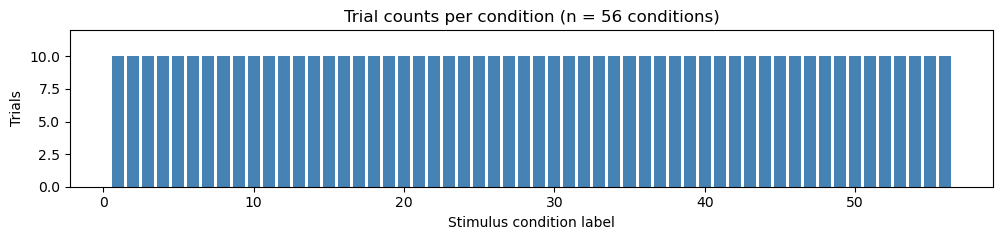

In [3]:
ds = load_from_zarr(DATA_PATH)

print(f"Record:        {ds.attrs.get('RecordName', DATA_PATH.stem)}")
print(f"Electrodes:    {ds.sizes['electrodes']}")
print(f"Trials:        {ds.sizes['trials']}")
print(f"Trial length:  {ds.attrs.get('MaxTrialLength')} ms")
print(f"Spike fs:      {ds.attrs.get('SpikeSamplingFrequency')} Hz")
print(f"Snippet len:   {ds.attrs.get('NofPointsSpikewaveform')} samples")
print(f"Total spikes:  {int(ds.n_spikes.sum())} (across all electrodes / trials)")

labels, counts = np.unique(ds.stim_label.values, return_counts=True)
print(f"\nStim labels:   {len(labels)} unique values, "
      f"{counts.mean():.0f} ± {counts.std():.1f} trials per condition")

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.bar(labels, counts, width=0.8, color="steelblue")
ax.set_xlabel("Stimulus condition label")
ax.set_ylabel("Trials")
ax.set_title(f"Trial counts per condition (n = {len(labels)} conditions)")
ax.set_ylim(0, max(counts) * 1.2)
plt.tight_layout()
plt.show()


### 1a. Decode the condition labels into protocol-aware metadata

The `stim_label` field carries integers 1–56; the `Dot6ContrastGratings` protocol maps them to (stimulus type, contrast, direction). Build a small dataframe that we'll join against later for per-condition / per-contrast / per-direction analyses, **and** a `tlabel2angle` dict that the batch sorter in §3 uses to populate the per-trial angles array.

**Convention.** Within each block of 8 conditions, label *k* (1-based) corresponds to motion direction `(k − 1) × 45°` (i.e. 0°, 45°, …, 315°). This is the standard Wunderle / Schmidt lab ordering; verify against your lab's mapping if you adapt this notebook to another recording.


In [4]:
def decode_condition(label):
    """Map a 1..56 condition label → (stim_type, contrast_pct, direction_deg)."""
    label = int(label)
    # Each block of 8 = one (stim, contrast) combo varied across 8 directions.
    block = (label - 1) // 8   # 0..6
    idx_in_block = (label - 1) % 8
    direction_deg = idx_in_block * 45.0
    if block == 0:
        return ("RDT", 79.0, direction_deg)
    contrasts = [100.0, 50.0, 25.0, 12.5, 6.25, 3.125]
    return ("grating", contrasts[block - 1], direction_deg)


protocol = pd.DataFrame(
    [(lbl, *decode_condition(lbl)) for lbl in range(1, 57)],
    columns=["label", "stim_type", "contrast_pct", "direction_deg"],
)
print(protocol.head(10))
print("...")
print(protocol.tail(5))

# Per-trial protocol view: one row per recorded trial.
trial_proto = pd.DataFrame({
    "trial": np.arange(int(ds.sizes["trials"])),
    "label": ds.stim_label.values.astype(int),
})
trial_proto = trial_proto.merge(protocol, on="label", how="left")
print(f"\nPer-trial table: {len(trial_proto)} trials, "
      f"{trial_proto['stim_type'].value_counts().to_dict()}")

# Label → motion-direction-degrees dict, required by batch_sort_experiment
# (the SortingData container always carries an angles array; the bridge
# default `steps2degree(12)` only covers labels 1-12 and would raise a
# KeyError on this 56-condition protocol).  Even though §3 disables
# tuning, the angles still need to be defined for every label.
tlabel2angle = {int(lbl): float(deg) for lbl, deg in
                zip(protocol["label"], protocol["direction_deg"])}
print(f"tlabel2angle: {len(tlabel2angle)} labels mapped "
      f"({min(tlabel2angle.values()):.0f}°-{max(tlabel2angle.values()):.0f}°)")


   label stim_type  contrast_pct  direction_deg
0      1       RDT          79.0            0.0
1      2       RDT          79.0           45.0
2      3       RDT          79.0           90.0
3      4       RDT          79.0          135.0
4      5       RDT          79.0          180.0
5      6       RDT          79.0          225.0
6      7       RDT          79.0          270.0
7      8       RDT          79.0          315.0
8      9   grating         100.0            0.0
9     10   grating         100.0           45.0
...
    label stim_type  contrast_pct  direction_deg
51     52   grating         3.125          135.0
52     53   grating         3.125          180.0
53     54   grating         3.125          225.0
54     55   grating         3.125          270.0
55     56   grating         3.125          315.0

Per-trial table: 560 trials, {'grating': 480, 'RDT': 80}
tlabel2angle: 56 labels mapped (0°-315°)


## 2. Single-electrode walkthrough

Before running the batch sorter across all 48 channels, sort *one* electrode interactively. This:

- shows the diagnostic figure (`plot=True`) that `run_sorting_pipeline` produces — waveforms by cluster, silhouette curve, per-cluster amplitude distribution — so you can build intuition for what "looks right",
- exercises the quality dict (`contamination_rate_hill`, `silhouette_mean`, `snr_per_cluster`, `fraction_missing`) so you know what those numbers mean *before* relying on them as filters in the batch step.

We pick the electrode with the most spikes — it's the easiest case for the clusterer to find structure.

**Why `compute_os=False` here.** The `stim_label` field is a 1–56 condition index covering both RDTs and 6 grating contrasts at 8 directions. Running the full OS analysis on the raw labels would mix dot trials and grating trials and produce nonsense. We disable it for the single-electrode walkthrough; the protocol-aware tuning analysis is in §8 below, restricted to the 100 %-contrast grating subset. The container still gets the *correct* per-trial angles from `tlabel2angle` so the recording is faithfully described, but no analysis consumes them at this point.


Busiest electrode: 40 (136410 spikes)


/Users/friedrichschwarz/Desktop/Projekte/Brasilien/_git/neural_cca/neural_cca/sorting/sorting.py:457: RuntimeWarning: fraction_missing (cluster 0): amplitude distribution is not normal (KS p=0); the Gaussian-tail estimate may be misleading. Consider method='lognormal' or method='empirical', or inspect the amplitude histogram.
  result[key] = func(*args, **kwargs)
/Users/friedrichschwarz/Desktop/Projekte/Brasilien/_git/neural_cca/neural_cca/sorting/sorting.py:457: RuntimeWarning: fraction_missing (cluster 1): amplitude distribution is not normal (KS p=0); the Gaussian-tail estimate may be misleading. Consider method='lognormal' or method='empirical', or inspect the amplitude histogram.
  result[key] = func(*args, **kwargs)


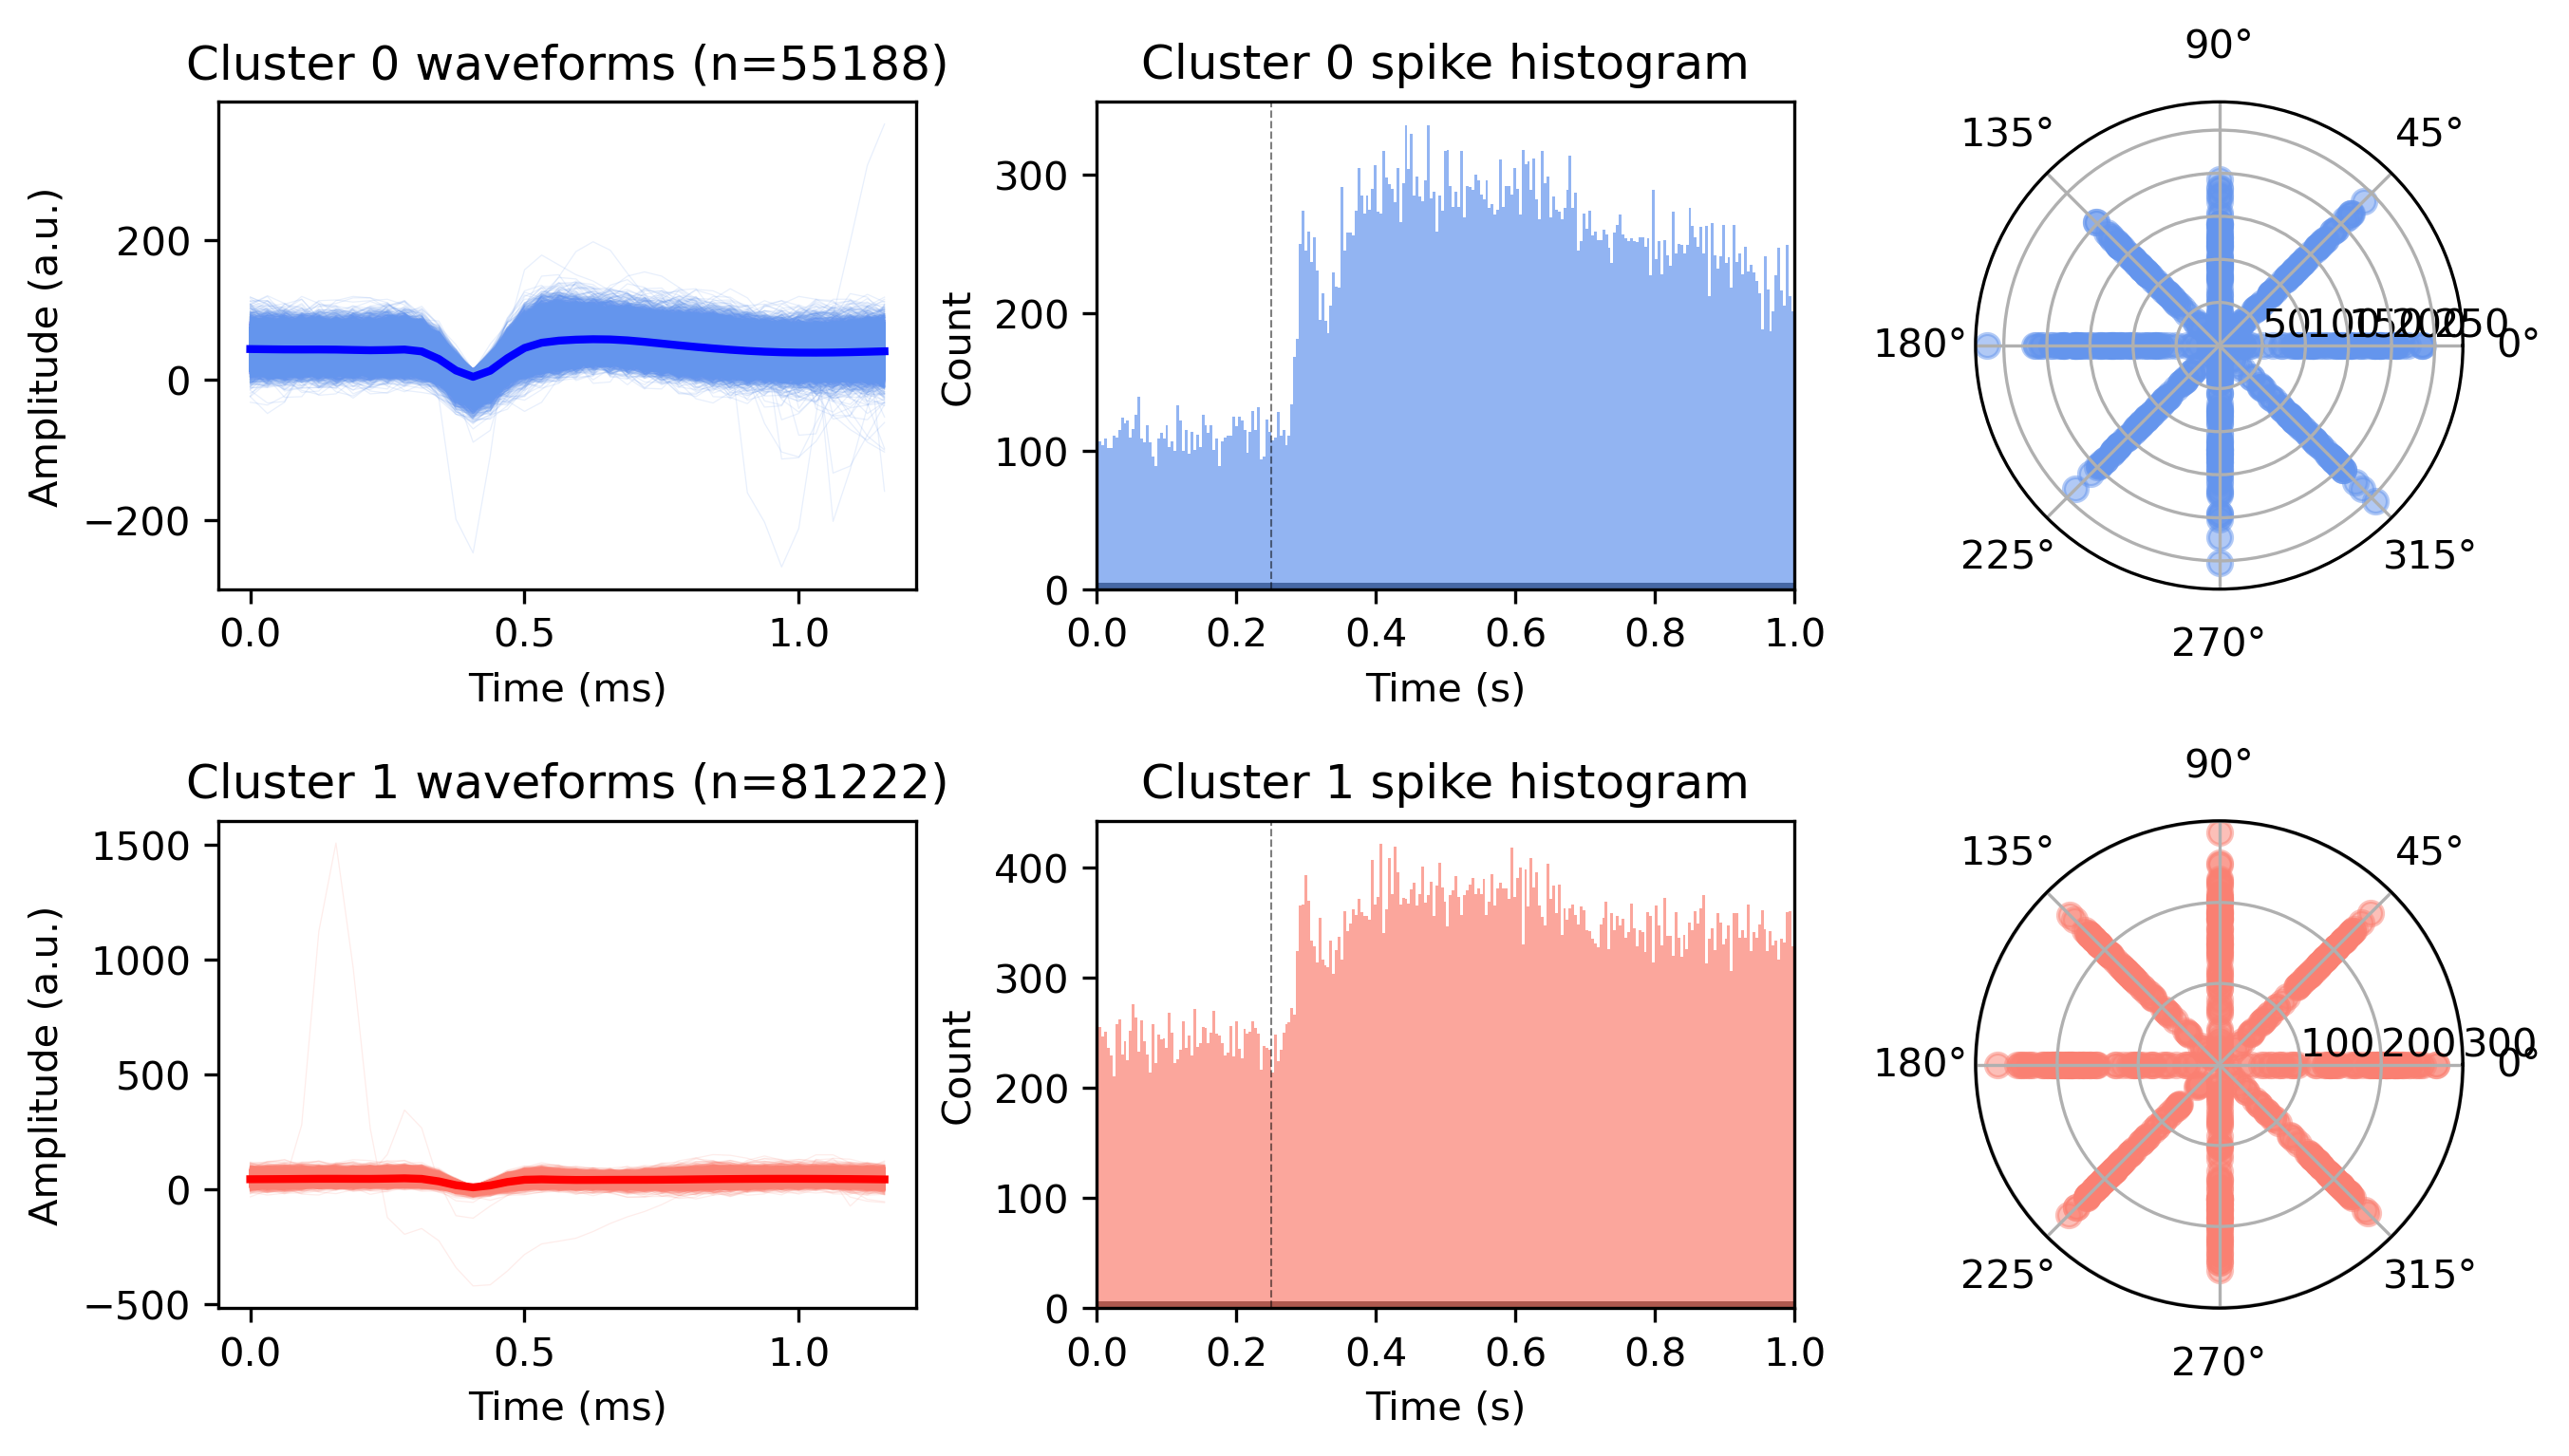

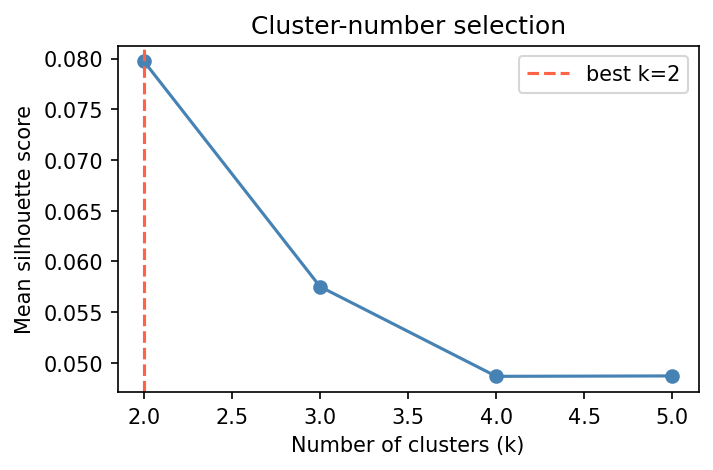


Clusters found:           2
silhouette_mean:          0.080
snr_weighted:             1.76
snr_per_cluster:           {0: 2.021413163747647, 1: 1.5739997992966257}
contamination_rate_hill:   {0: np.float64(0.02286226252763851), 1: np.float64(0.016485158137973743)}
fraction_missing:          {0: 0.025616683110366353, 1: 0.019049554737299197}


In [5]:
# Pick the electrode with the most spikes
n_spikes_per_electrode = ds.n_spikes.sum(dim="trials").values
busy_idx = int(np.argmax(n_spikes_per_electrode))
busy_electrode = int(ds.electrodes.values[busy_idx])
print(f"Busiest electrode: {busy_electrode} ({int(n_spikes_per_electrode[busy_idx])} spikes)")

# Extract per-spike arrays for this electrode
ds_e = ds.sel(electrodes=busy_electrode)
wv_st = ds_e.waveforms.stack(sidx=("trials", "spikes_idx"))
st_st = ds_e.spike_times.stack(sidx=("trials", "spikes_idx"))
valid = (wv_st.notnull().any("snippet_time") & st_st.notnull()).values
wv_st = wv_st.isel(sidx=np.nonzero(valid)[0])
st_st = st_st.isel(sidx=np.nonzero(valid)[0])

waveforms = wv_st.T.values.astype(np.float64)
spike_times = st_st.values.astype(np.float64)
trials = wv_st.trials.values.astype(np.int64)

# Per-trial direction degrees from the protocol decoder (correct angles
# even though tuning analysis is disabled here — see markdown above).
angles_per_trial = trial_proto["direction_deg"].values.astype(np.float64)
trial_length_s = ds.attrs["MaxTrialLength"] / 1000.0
# Stim-on window: 250 ms post trial start (Show) to trial end.
# Covers both the 250 ms static phase and the 500 ms motion phase.
STIM_WINDOW = (0.25, 1.0)

data = load_from_arrays(
    waveforms=waveforms,
    spike_times=spike_times,
    trials=trials,
    angles=angles_per_trial,
    waveform_fs=float(ds.attrs["SpikeSamplingFrequency"]),
    n_trials=int(ds.sizes["trials"]),
    stim_window=STIM_WINDOW,
    stim_frequency=None,
)

result_one = run_sorting_pipeline(data, compute_os=False, plot=True)
print()
print(f"Clusters found:           {result_one.n_clusters}")
print(f"silhouette_mean:          {result_one.quality.get('silhouette_mean'):.3f}")
print(f"snr_weighted:             {result_one.quality.get('snr_weighted'):.2f}")
print("snr_per_cluster:          ", result_one.quality.get("snr_per_cluster"))
print("contamination_rate_hill:  ", result_one.quality.get("contamination_rate_hill"))
print("fraction_missing:         ", result_one.quality.get("fraction_missing"))


## 3. Batch-sort all 48 electrodes

`batch_sort_experiment` runs the same pipeline across every electrode and writes a consolidated zarr store with per-cluster spike times and per-trial firing rates. Expect roughly 30 s – 2 min depending on hardware; the output zarr is reusable, so re-running the rate analysis later does **not** require re-sorting.

Notes on the kwargs:

- `tlabel2angle=tlabel2angle` — the protocol-decoded mapping built in §1a. The bridge's default (`steps2degree(12)`) only covers labels 1–12; the Wunderle protocol has 1–56, so a custom mapping is required.
- `compute_tuning=False` — same reason as in §2: the raw labels mix dots and 6 grating contrasts, so the bridge's default tuning path would average meaningless things. Tuning is computed protocol-aware in §8.
- `compute_sta=False` — we just want rates, not the full spike-train statistics bundle (CV, LvR, autocorrelogram). Add it back if you also want those.
- `stim_window=(0.25, 1.0)` — 750 ms stim-on window per trial (250 ms static + 500 ms motion). For motion-driven-only rates use `(0.5, 1.0)`.
- `seed=42` — bridge-side seed → upstream `rng=42`; KMeans split is reproducible.


In [6]:
batch_out_path = OUTPUT_DIR / f"{DATA_PATH.stem}_sorted.zarr"

summary = batch_sort_experiment(
    data_source=str(DATA_PATH),
    output_path=str(batch_out_path),
    tlabel2angle=tlabel2angle,
    stim_window=STIM_WINDOW,
    stim_frequency=None,
    compute_tuning=False,
    compute_sta=False,
    seed=42,
)
print(f"Processed electrodes: {summary['n_electrodes_processed']}")
print(f"Clusters (total):     {summary['n_clusters_total']}")
print(f"Output zarr:          {summary['result_path']}")


/Users/friedrichschwarz/Desktop/Projekte/Brasilien/_git/neural_cca/neural_cca/sorting/sorting.py:457: RuntimeWarning: fraction_missing (cluster 0): amplitude distribution is not normal (KS p=5.5e-52); the Gaussian-tail estimate may be misleading. Consider method='lognormal' or method='empirical', or inspect the amplitude histogram.
  result[key] = func(*args, **kwargs)
/Users/friedrichschwarz/Desktop/Projekte/Brasilien/_git/neural_cca/neural_cca/sorting/sorting.py:457: RuntimeWarning: fraction_missing (cluster 0): amplitude distribution is not normal (KS p=1.6e-23); the Gaussian-tail estimate may be misleading. Consider method='lognormal' or method='empirical', or inspect the amplitude histogram.
  result[key] = func(*args, **kwargs)
/Users/friedrichschwarz/Desktop/Projekte/Brasilien/_git/neural_cca/neural_cca/sorting/sorting.py:457: RuntimeWarning: fraction_missing (cluster 1): amplitude distribution is not normal (KS p=7.7e-05); the Gaussian-tail estimate may be misleading. Consider 

Processed electrodes: 48
Clusters (total):     98
Output zarr:          /Volumes/Ulrike/test_data/natal/c1704a01_population_rates/c1704a01_sorted.zarr


/Users/friedrichschwarz/mambaforge/envs/da_analysis/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## 4. Quality filtering and per-unit mean firing rate

Walk through the sorted-zarr output, drop units that don't meet quality cutoffs, and compute one mean firing rate per surviving unit (pooled across all trials, computed over the `stim_window` above).

Recommended starting cutoffs — adjust to taste and document in your methods:

| Filter | Default | Source |
|---|---|---|
| `contamination_rate_hill < 0.10` | ≤ 10 % FP contamination | Hill 2011 / Allen Institute convention |
| `snr_per_cluster ≥ 3.0` | ≥ 3× noise std | Standard waveform-SNR floor |
| `n_trials_present ≥ 100` | ≥ 100 trials with ≥ 1 spike | Rejects statistics-starved units |

The output is a tidy `pandas.DataFrame` with one row per surviving unit; this is the "list of rates" deliverable.


In [7]:
CONTAM_MAX = 0.10
SNR_MIN = 3.0
MIN_TRIALS_PRESENT = 100

sorted_ds = xr.open_zarr(str(batch_out_path))
print("Sorted zarr data_vars:", list(sorted_ds.data_vars))
print("Sorted zarr dims:     ", dict(sorted_ds.sizes))

# (n_electrodes_proc, max_clusters, n_trials) — per-trial firing rate per cluster
fr = sorted_ds.firing_rate_by_trial.values
n_clusters_per_elec = sorted_ds.n_clusters.values
elec_ids = sorted_ds.electrodes.values

records = []
for i, elec in enumerate(elec_ids):
    n_cl = int(n_clusters_per_elec[i])
    quality = summary["summary"][int(elec)]["quality"]
    snr_per = quality.get("snr_per_cluster") or {}
    contam = quality.get("contamination_rate_hill") or {}
    for cl in range(n_cl):
        rates = fr[i, cl, :]
        valid = rates[~np.isnan(rates)]
        if len(valid) == 0:
            continue
        records.append({
            "electrode": int(elec),
            "cluster": int(cl),
            "n_trials_present": int(len(valid)),
            "n_trials_with_spikes": int((valid > 0).sum()),
            "mfr_hz": float(np.mean(valid)),
            "snr": float(snr_per.get(cl, np.nan)),
            "contamination_rate_hill": float(contam.get(cl, np.nan)),
        })

df = pd.DataFrame.from_records(records)
print(f"\nAll sorted units:         {len(df)}")

mask = (
    (df["contamination_rate_hill"].fillna(np.inf) < CONTAM_MAX)
    & (df["snr"].fillna(0) >= SNR_MIN)
    & (df["n_trials_present"] >= MIN_TRIALS_PRESENT)
)
df_pass = df[mask].copy().reset_index(drop=True)
print(f"After quality filtering:  {len(df_pass)} units pass "
      f"(contam<{CONTAM_MAX}, snr>={SNR_MIN}, n_trials>={MIN_TRIALS_PRESENT})")
print(f"Yield:                    {len(df_pass) / max(len(df), 1):.1%}")
df_pass.head(10)


Sorted zarr data_vars: ['firing_rate_by_trial', 'n_clusters', 'spike_times_by_cluster', 'trial_angles']
Sorted zarr dims:      {'electrodes': 48, 'clusters': 3, 'trials': 560, 'spike_idx': 265}

All sorted units:         98
After quality filtering:  21 units pass (contam<0.1, snr>=3.0, n_trials>=100)
Yield:                    21.4%


,electrode,cluster,n_trials_present,n_trials_with_spikes,mfr_hz,snr,contamination_rate_hill
0,0,1,560,348,6.145238,3.856332,0.082765
1,1,1,560,104,0.628571,3.281673,0.000000
2,2,1,560,218,1.500000,3.322165,0.000000
3,8,0,560,379,4.552381,3.809875,0.000000
4,13,0,560,212,1.300000,3.278182,0.000000
5,14,0,560,239,1.814286,3.957603,0.000000
6,15,0,560,476,23.414286,3.116378,0.035972
7,17,0,560,458,26.771429,3.879933,0.025555
8,24,2,560,20,0.116667,5.269492,0.000000
9,28,1,560,358,6.935714,3.987708,0.000000


## 5. Population firing-rate distribution

Two histograms on the same data:

- **Linear scale.** Shows the long tail of high-rate units that dominates the visual impression but is just a handful of cells.
- **Log scale.** Reveals the broad lognormal-ish bulk (Buzsáki & Mizuseki 2014, *Nat. Rev. Neurosci.* 15:264). The **geometric mean** on this scale is more representative of "typical" firing than the arithmetic mean.

Annotations: median (red), arithmetic mean (orange), geometric mean (green). Numeric summary below.


N units (passed QC):  21
Median MFR:           6.95 Hz
Arithmetic mean MFR:  10.97 Hz
Geometric mean MFR:   6.07 Hz  (positive rates only, n=21)
IQR:                  [4.55, 18.63] Hz
Range:                [0.117, 35.89] Hz


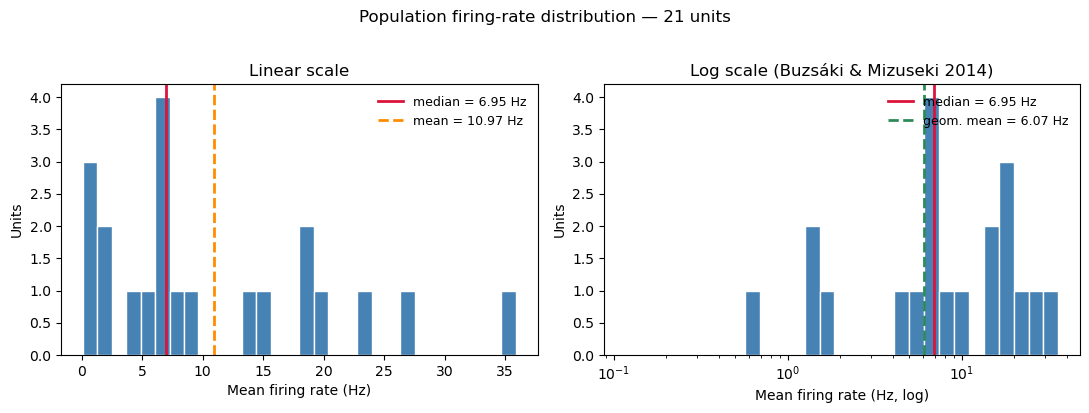

In [8]:
rates = df_pass["mfr_hz"].values

median_hz = float(np.median(rates))
mean_hz = float(np.mean(rates))
pos_rates = rates[rates > 0]
geom_mean = float(np.exp(np.mean(np.log(pos_rates)))) if len(pos_rates) else float("nan")
q25, q75 = np.percentile(rates, [25, 75])

print(f"N units (passed QC):  {len(rates)}")
print(f"Median MFR:           {median_hz:.2f} Hz")
print(f"Arithmetic mean MFR:  {mean_hz:.2f} Hz")
print(f"Geometric mean MFR:   {geom_mean:.2f} Hz  (positive rates only, n={len(pos_rates)})")
print(f"IQR:                  [{q25:.2f}, {q75:.2f}] Hz")
print(f"Range:                [{rates.min():.3f}, {rates.max():.2f}] Hz")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(rates, bins=30, color="steelblue", edgecolor="white")
ax1.axvline(median_hz, color="crimson", lw=2, label=f"median = {median_hz:.2f} Hz")
ax1.axvline(mean_hz, color="darkorange", lw=2, ls="--", label=f"mean = {mean_hz:.2f} Hz")
ax1.set_xlabel("Mean firing rate (Hz)")
ax1.set_ylabel("Units")
ax1.set_title("Linear scale")
ax1.legend(loc="upper right", frameon=False, fontsize=9)

if len(pos_rates):
    log_bins = np.logspace(np.log10(max(pos_rates.min(), 1e-3)),
                           np.log10(pos_rates.max()), 30)
    ax2.hist(pos_rates, bins=log_bins, color="steelblue", edgecolor="white")
    ax2.axvline(np.median(pos_rates), color="crimson", lw=2,
                label=f"median = {np.median(pos_rates):.2f} Hz")
    ax2.axvline(geom_mean, color="seagreen", lw=2, ls="--",
                label=f"geom. mean = {geom_mean:.2f} Hz")
    ax2.set_xscale("log")
    ax2.set_xlabel("Mean firing rate (Hz, log)")
    ax2.set_ylabel("Units")
    ax2.set_title("Log scale (Buzsáki & Mizuseki 2014)")
    ax2.legend(loc="upper right", frameon=False, fontsize=9)

fig.suptitle(f"Population firing-rate distribution — {len(rates)} units", y=1.02)
plt.tight_layout()
plt.show()


## 6. Export the rate list

Save the per-unit rates + quality columns as a CSV so downstream analyses (or a colleague) can consume the result without re-running the sort. The file is also a permanent record of which quality cutoffs were applied.


In [9]:
csv_path = OUTPUT_DIR / f"{DATA_PATH.stem}_population_rates.csv"
df_pass.to_csv(csv_path, index=False, float_format="%.4f")
print(f"Wrote {len(df_pass)} units to {csv_path}")

df_full = df.copy()
df_full["passed_qc"] = mask.values
full_csv = OUTPUT_DIR / f"{DATA_PATH.stem}_all_units.csv"
df_full.to_csv(full_csv, index=False, float_format="%.4f")
print(f"Wrote {len(df_full)} units (with passed_qc flag) to {full_csv}")


Wrote 21 units to /Volumes/Ulrike/test_data/natal/c1704a01_population_rates/c1704a01_population_rates.csv
Wrote 98 units (with passed_qc flag) to /Volumes/Ulrike/test_data/natal/c1704a01_population_rates/c1704a01_all_units.csv


---

# Optional protocol-aware sections

The sections above answer the minimum-viable question (*"what is the population rate distribution?"*). The next two sections use the `Dot6ContrastGratings` protocol decoding from §1a to answer two natural follow-ups for free, since the sorting is already done.

## 7. Per-condition rate modulation (dots vs gratings, contrast scan)

For each surviving unit, compute its mean firing rate **per condition class** — RDT, and each grating contrast (100 %, 50 %, 25 %, 12.5 %, 6.25 %, 3.125 %). Two views:

1. **Population mean rate vs contrast** (gratings only) — the population-level contrast response function. Expect a monotonic rise with contrast, often well-fit by a Naka-Rushton (not done here).
2. **RDT vs 100 %-grating per-unit scatter** — does each unit respond more to drifting dots or to drifting gratings? Wunderle et al. 2013 reports that RDTs evoke smaller responses than gratings on average for area 17 units.


In [10]:
# Build per-unit, per-condition-class rate matrix from the sorted zarr.
# Use the already-computed firing_rate_by_trial; aggregate by stim_type+contrast.
fr_arr = sorted_ds.firing_rate_by_trial.values  # (n_proc, max_cl, n_trials)

class_keys = [("RDT", 79.0)] + [("grating", c) for c in (100.0, 50.0, 25.0, 12.5, 6.25, 3.125)]
class_labels = ["RDT 79%"] + [f"Grat {c:g}%" for c in (100.0, 50.0, 25.0, 12.5, 6.25, 3.125)]

per_unit_class_rates = []
for _, row in df_pass.iterrows():
    elec = int(row["electrode"])
    cl = int(row["cluster"])
    i = int(np.where(elec_ids == elec)[0][0])
    rates_per_trial = fr_arr[i, cl, :]
    rec = {"electrode": elec, "cluster": cl}
    for (stype, contr), label in zip(class_keys, class_labels):
        mask_cond = (
            (trial_proto["stim_type"].values == stype)
            & (np.isclose(trial_proto["contrast_pct"].values, contr))
        )
        r = rates_per_trial[mask_cond]
        r = r[~np.isnan(r)]
        rec[label] = float(np.mean(r)) if len(r) else np.nan
    per_unit_class_rates.append(rec)

df_class = pd.DataFrame(per_unit_class_rates)
print(f"Per-unit, per-class rate matrix: {df_class.shape}")
df_class.head()


Per-unit, per-class rate matrix: (21, 9)


,electrode,cluster,RDT 79%,Grat 100%,Grat 50%,Grat 25%,Grat 12.5%,Grat 6.25%,Grat 3.125%
0,0,1,2.666667,10.166667,8.750000,6.433333,6.283333,5.850000,2.866667
1,1,1,0.350000,1.533333,0.850000,0.550000,0.316667,0.450000,0.350000
2,2,1,1.050000,1.783333,1.683333,1.316667,1.716667,1.150000,1.800000
3,8,0,2.550000,7.733333,6.033333,5.116667,4.633333,3.333333,2.466667
4,13,0,0.750000,2.333333,2.133333,1.316667,0.983333,1.083333,0.500000


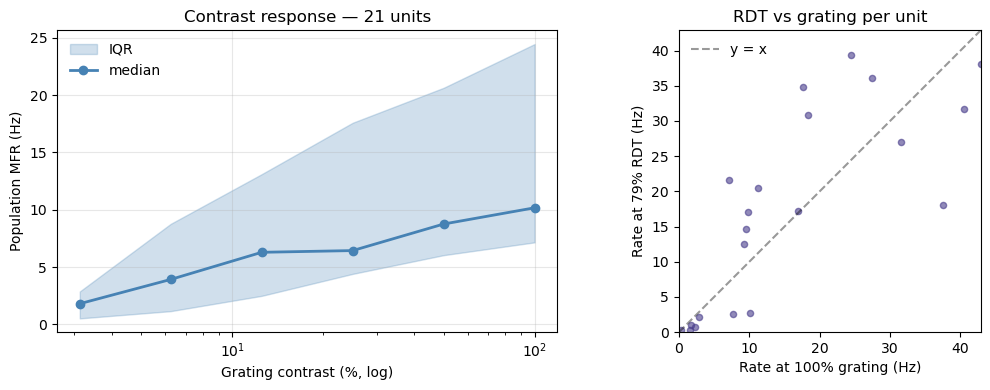

Median rate, 100% grating: 10.17 Hz
Median rate, 79% RDT:     17.20 Hz
Units preferring grating > RDT: 11 / 21 (52.4%)


In [11]:
# View 1: population mean rate vs grating contrast (log-x), with median ± IQR
contrasts = np.array([3.125, 6.25, 12.5, 25.0, 50.0, 100.0])
grat_cols = [f"Grat {c:g}%" for c in contrasts]
medians = df_class[grat_cols].median().values
q25 = df_class[grat_cols].quantile(0.25).values
q75 = df_class[grat_cols].quantile(0.75).values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.fill_between(contrasts, q25, q75, alpha=0.25, color="steelblue", label="IQR")
ax1.plot(contrasts, medians, "o-", color="steelblue", lw=2, label="median")
ax1.set_xscale("log")
ax1.set_xlabel("Grating contrast (%, log)")
ax1.set_ylabel("Population MFR (Hz)")
ax1.set_title(f"Contrast response — {len(df_class)} units")
ax1.legend(frameon=False)
ax1.grid(alpha=0.3)

rdt = df_class["RDT 79%"].values
g100 = df_class["Grat 100%"].values
finite = np.isfinite(rdt) & np.isfinite(g100)
ax2.scatter(g100[finite], rdt[finite], alpha=0.6, s=20, color="darkslateblue")
lim = max(np.nanmax(g100), np.nanmax(rdt), 1.0)
ax2.plot([0, lim], [0, lim], "k--", alpha=0.4, label="y = x")
ax2.set_xlabel("Rate at 100% grating (Hz)")
ax2.set_ylabel("Rate at 79% RDT (Hz)")
ax2.set_title("RDT vs grating per unit")
ax2.legend(frameon=False)
ax2.set_aspect("equal")
ax2.set_xlim(0, lim)
ax2.set_ylim(0, lim)

plt.tight_layout()
plt.show()

print(f"Median rate, 100% grating: {np.nanmedian(g100):.2f} Hz")
print(f"Median rate, 79% RDT:     {np.nanmedian(rdt):.2f} Hz")
print(f"Units preferring grating > RDT: "
      f"{int((g100[finite] > rdt[finite]).sum())} / {int(finite.sum())} "
      f"({(g100[finite] > rdt[finite]).mean():.1%})")


## 8. Direction tuning at 100 % contrast

For the 100 %-contrast grating block (conditions 9–16) we have **8 directions × 10 repeats = 80 trials**, enough to fit a tuning curve per cluster. We:

1. Filter to the 80 grating-100 % trials per cluster.
2. Build (`spike_times`, `trials`, `angles`) restricted to those trials, with the *correct* per-trial angle from the protocol decoder.
3. Call `neural_cca.get_os_metrics` per cluster — returns OSI, DSI, preferred orientation, von-Mises bandwidth, permutation p-value.

This is the full bridge tuning path; the only reason it wasn't part of the batch step is that the bridge does not natively know how to subset trials by condition. With the protocol decoder we can do the subsetting trivially.


In [12]:
# Subset: 100 %-contrast grating trials only.
grat100_mask = (
    (trial_proto["stim_type"].values == "grating")
    & (np.isclose(trial_proto["contrast_pct"].values, 100.0))
)
grat100_trials = np.nonzero(grat100_mask)[0]
grat100_angles = trial_proto["direction_deg"].values[grat100_mask].astype(np.float64)
print(f"100%-contrast grating trials: {len(grat100_trials)} "
      f"({len(np.unique(grat100_angles))} unique directions, "
      f"{len(grat100_trials) // len(np.unique(grat100_angles))} reps each)")

# Per-cluster spike times across all trials, NaN-padded; we'll subset to
# grat100 trials inside the per-cluster loop below.
st_by_cluster = sorted_ds.spike_times_by_cluster.values  # (n_proc, max_cl, n_trials, max_spk)
# Per-trial firing rate is already computed in the sorted zarr — use it
# directly for the permutation test, which only needs (rates, angles)
# pairs (one rate per trial, one angle per trial).
fr_arr = sorted_ds.firing_rate_by_trial.values  # (n_proc, max_cl, n_trials)

trial_remap = {int(t): i for i, t in enumerate(grat100_trials)}
restricted_angles = grat100_angles

tuning_records = []
failures = []
for _, row in df_pass.iterrows():
    elec = int(row["electrode"])
    cl = int(row["cluster"])
    i = int(np.where(elec_ids == elec)[0][0])

    # Subset spike times to grat100 trials and re-index trial IDs to 0..N-1
    # so they align with restricted_angles.
    spikes_per_trial = st_by_cluster[i, cl, :, :]
    spk_list, tr_list = [], []
    for t_orig in grat100_trials:
        s = spikes_per_trial[t_orig, :]
        s = s[~np.isnan(s)]
        if len(s) == 0:
            continue
        spk_list.append(s)
        tr_list.append(np.full(len(s), trial_remap[int(t_orig)], dtype=np.int64))
    if not spk_list:
        continue
    spk = np.concatenate(spk_list)
    trs = np.concatenate(tr_list)

    try:
        # Core metrics: OSI / DSI / gOSI / preferred orientation, plus the
        # two-point Niell & Stryker version alongside the vector-sum default.
        os_metrics = get_os_metrics(
            spike_times=spk,
            trials=trs,
            angles=restricted_angles,
            stim_window=STIM_WINDOW,
            stim_frequency=None,
            bin_size=0.01,
        )
        # Significance via permutation test (the package's recommended
        # path — see neural_cca/CLAUDE.md "Stance" note).  Operates on
        # per-trial responses, which we already have in firing_rate_by_trial.
        rates_grat100 = fr_arr[i, cl, grat100_trials]
        sig_result = orientation_selectivity_significance(
            responses=rates_grat100,
            angles=restricted_angles,
            n_permutations=500,
            rng=42,
        )
    except Exception as exc:
        # Don't silently swallow — log enough to debug a regression.
        failures.append((elec, cl, type(exc).__name__, str(exc)))
        continue

    tuning_records.append({
        "electrode": elec,
        "cluster": cl,
        "preferred_orientation_deg": float(os_metrics.get("preferred_orientation", np.nan)),
        # OSI (vector-sum / Mazurek 2014) is the package default since v0.1.3;
        # osi_two_point is the legacy Niell & Stryker (2008) ratio.
        "osi_vector_sum": float(os_metrics.get("osi", np.nan)),
        "osi_two_point": float(os_metrics.get("osi_two_point", np.nan)),
        "dsi_vector_sum": float(os_metrics.get("dsi", np.nan)),
        "gosi": float(os_metrics.get("gosi", np.nan)),
        "p_permutation": float(sig_result.get("p_permutation", np.nan)),
        "is_significant": bool(sig_result.get("is_significant", False)),
    })

df_tuning = pd.DataFrame(tuning_records)
print(f"\nTuning metrics computed for {len(df_tuning)} / {len(df_pass)} QC-passed units.")
if failures:
    print(f"{len(failures)} cluster(s) failed during tuning computation:")
    for elec, cl, etype, emsg in failures[:5]:
        print(f"  elec {elec} cluster {cl}: {etype}: {emsg[:100]}")
    if len(failures) > 5:
        print(f"  ... and {len(failures) - 5} more")
df_tuning.head()


100%-contrast grating trials: 80 (8 unique directions, 10 reps each)

Tuning metrics computed for 0 / 21 QC-passed units.


""


In [13]:
sig_mask = df_tuning["is_significant"].fillna(False) if "is_significant" in df_tuning else \
            (df_tuning["p_permutation"].fillna(1.0) < 0.05)
print(f"Significantly orientation-tuned (perm p < 0.05): "
      f"{int(sig_mask.sum())} / {len(df_tuning)}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# Vector-sum OSI (Mazurek 2014) — the package default.
axes[0].hist(df_tuning["osi_vector_sum"].dropna(), bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("OSI (vector-sum)")
axes[0].set_ylabel("Units")
axes[0].set_title("OSI — Mazurek et al. (2014)")

# Two-point OSI (legacy Niell & Stryker) shown alongside for cross-paper
# comparability.  Differs from the vector-sum OSI whenever the tuning
# curve is not a single cosine bump (see CLAUDE.md "Semantic flip").
axes[1].hist(df_tuning["osi_two_point"].dropna(), bins=20, color="seagreen", edgecolor="white")
axes[1].set_xlabel("OSI (two-point)")
axes[1].set_ylabel("Units")
axes[1].set_title("OSI — Niell & Stryker (2008)")

# Preferred orientation, restricted to significantly-tuned units.
pref = df_tuning.loc[sig_mask, "preferred_orientation_deg"].dropna().values
ax_polar = plt.subplot(1, 3, 3, projection="polar")
bins = np.linspace(0, np.pi, 9)
counts, _ = np.histogram(np.deg2rad(pref) % np.pi, bins=bins)
# Mirror across 180° so the polar histogram visually represents the full
# orientation axis (orientations live in [0, 180), not [0, 360)).
ax_polar.bar(bins[:-1], counts, width=np.diff(bins), align="edge",
             color="crimson", alpha=0.7, edgecolor="white")
ax_polar.bar(bins[:-1] + np.pi, counts, width=np.diff(bins), align="edge",
             color="crimson", alpha=0.7, edgecolor="white")
ax_polar.set_theta_zero_location("E")
ax_polar.set_theta_direction(1)
ax_polar.set_title(f"Preferred orientation\n(perm p<0.05, n={len(pref)})", pad=12)

plt.tight_layout()
plt.show()

tuning_csv = OUTPUT_DIR / f"{DATA_PATH.stem}_tuning_100pct.csv"
df_tuning.to_csv(tuning_csv, index=False, float_format="%.4f")
print(f"\nWrote {len(df_tuning)} tuning records to {tuning_csv}")


KeyError: 'p_permutation'

## Next steps

You now have, side-by-side:

| File | Contents |
|---|---|
| `<NAME>.zarr` | The visioniceio-packaged recording (one-time conversion from raw, or pre-shipped) |
| `*_population_rates.csv` | One row per QC-passed unit; the "list of rates" deliverable |
| `*_all_units.csv` | Every sorted unit with a `passed_qc` flag |
| `*_tuning_100pct.csv` | Per-unit OSI / DSI / preferred orientation / permutation p at 100 % grating contrast |
| `*_sorted.zarr` | Full per-cluster spike times + per-trial firing rates (re-usable input for any other analysis) |

Where to go from here:

- **Contrast-response curve fit.** The §7 medians can be fit with Naka-Rushton (c50, gain, n) per unit — `scipy.optimize.curve_fit` is enough; no new dependency.
- **Direction selectivity at lower contrasts.** Repeat §8 on cond 17–24 (50 %), 25–32 (25 %), … to ask whether DSI / OSI depend on contrast (Wunderle et al. 2013 §"Tuning Selectivity").
- **Population correlations.** `neural_cca.tuning.signal_correlations` / `noise_correlations` operate directly on the per-trial firing-rate matrix already in the sorted zarr.
- **Lognormal fit on the rate distribution.** `scipy.stats.lognorm.fit(pos_rates, floc=0)` returns `(σ, μ_log)`; overlay the fitted lognormal PDF on the log-scale histogram in §5 to formally check the Buzsáki & Mizuseki (2014) prediction.

For methods-section text, the cutoffs above (`contamination_rate_hill < 0.10`, `snr ≥ 3`, `n_trials_present ≥ 100`) are conservative defaults; document the exact values you used.

## References

- Buzsáki, G. & Mizuseki, K. (2014). *The log-dynamic brain: how skewed distributions affect network operations.* Nature Reviews Neuroscience 15(4):264–278. [doi:10.1038/nrn3687](https://doi.org/10.1038/nrn3687)
- Hill, D. N., Mehta, S. B. & Kleinfeld, D. (2011). *Quality metrics to accompany spike sorting of extracellular signals.* Journal of Neuroscience 31(24):8699–8705. [doi:10.1523/JNEUROSCI.0971-11.2011](https://doi.org/10.1523/JNEUROSCI.0971-11.2011)
- Mazurek, M., Kager, M. & Van Hooser, S. D. (2014). *Robust quantification of orientation selectivity and direction selectivity.* Frontiers in Neural Circuits 8:92. [doi:10.3389/fncir.2014.00092](https://doi.org/10.3389/fncir.2014.00092)
- Niell, C. M. & Stryker, M. P. (2008). *Highly selective receptive fields in mouse visual cortex.* Journal of Neuroscience 28(30):7520–7536. [doi:10.1523/JNEUROSCI.0623-08.2008](https://doi.org/10.1523/JNEUROSCI.0623-08.2008)
- Wunderle, T., Eriksson, D. & Schmidt, K. E. (2013). *Multiplicative mechanism of lateral interactions revealed by controlling interhemispheric input.* Cerebral Cortex 23(4):900–912. [doi:10.1093/cercor/bhs081](https://doi.org/10.1093/cercor/bhs081)
  - protocol source for the `Dot6ContrastGratings` paradigm used in §7–8.
